# Group-level permutation test between observed samples and surrogate samples (peak-to-peak shuffled)
In this tutorial, we will perform a permutation test between observed samples and surrogate samples (peak-to-peak shuffled) at group level to assess whether the observed samples are significantly different from what would be expected by chance. 

In [ ]:
import pickle as pkl
import numpy as np
from pathlib import Path
import math
import matplotlib.pyplot as plt

from pyriodic import Circular, CircPlot
from pyriodic.permutation import permutation_test_against_surrogate, permutation_test_within_units
from pyriodic.surrogate import surrogate_shuffle_breath_cycles

/Users/au661930/Library/CloudStorage/OneDrive-Aarhusuniversitet/Dokumenter/projects/_BehaviouralBreathing/code/AnalysisBreathingBehaviour/BreathingBehaviourVenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = Path("../../data/raw/intermediate")
circulars = {}
pas = {}
events_samples = {}


for file_path in data_path.iterdir(): 
    if not file_path.name.endswith(".pkl"):
        continue
    subj_id = file_path.name.split("_")[0]
    with open(file_path, 'rb') as f:
            data = pkl.load(f)
    circulars[subj_id] = data["circ"]
    pas[subj_id] = data["phase_ts"]
    behavioral_data = data["behav_data"]
    events_samples[subj_id] = behavioral_data["event_samples"]


In [4]:
rng = np.random.default_rng(seed=42)

results = {}

for subj_id in circulars:
    circ = circulars[subj_id]
    observed = circ["target"]
    pa = pas[subj_id]

    events_samp = events_samples[subj_id]
    labels = circ.labels

    # find the event samples for the target events in circ
    target_event_samples = [samp for samp, label in zip(events_samp, labels) if "target" in label]

    surr_samples = surrogate_shuffle_breath_cycles(pa, target_event_samples, n_surrogate=500, rng=rng)

    # Run participant-level permutation test
    obs_stat, pval, obs_vs_surr, surr_vs_surr = permutation_test_against_surrogate(
        observed.data,
        surrogate_samples=surr_samples,
        alternative="greater",
        n_permutations = 10000,
        return_obs_and_surr_stats=True
    )
    # per-participant summary stats (means of distributions)
    circ_surr_samples = Circular.from_multiple(
        [Circular(samp, labels=[i]*len(samp)) for i, samp in enumerate(surr_samples)]
    )

    results[subj_id] = {
        "obs_vs_surr": obs_vs_surr,
        "surr_vs_surr": surr_vs_surr,
        "pval": pval,
        "null_samples": circ_surr_samples
        }
    

100%|██████████| 500/500 [00:09<00:00, 54.77it/s] 


Generated 500 surrogate time series by shuffling breathing cycles.
p val: 9.999000099990002e-05, observed stat: 248778.000, mean null stat: 124959.336


100%|██████████| 500/500 [00:08<00:00, 58.31it/s] 


Generated 500 surrogate time series by shuffling breathing cycles.
p val: 9.999000099990002e-05, observed stat: 250000.000, mean null stat: 125037.666


100%|██████████| 500/500 [00:06<00:00, 71.66it/s] 


...

Generated 500 surrogate time series by shuffling breathing cycles.
p val: 9.999000099990002e-05, observed stat: 244729.000, mean null stat: 124964.490


100%|██████████| 500/500 [00:08<00:00, 56.19it/s] 


Generated 500 surrogate time series by shuffling breathing cycles.
p val: 9.999000099990002e-05, observed stat: 217631.500, mean null stat: 125026.536


100%|██████████| 500/500 [00:09<00:00, 52.27it/s]


Generated 500 surrogate time series by shuffling breathing cycles.
p val: 9.999000099990002e-05, observed stat: 238541.000, mean null stat: 124997.982


In [ ]:
surr = [results[subj_id]["surr_vs_surr"] for subj_id in results]
obs = [results[subj_id]["obs_vs_surr"] for subj_id in results]

group_obs_stat, group_pval, group_null = permutation_test_within_units(
    data1=obs,
    data2=surr,
    n_permutations=10000,
    alternative="greater",
    verbose=True,
    return_null_distribution=True
)

Generating null distribution: 100%|██████████| 10000/10000 [00:02<00:00, 3342.64it/s]

Observed statistic = 0.1141, p = 0.0001


### Is this effect consistent across all participants?

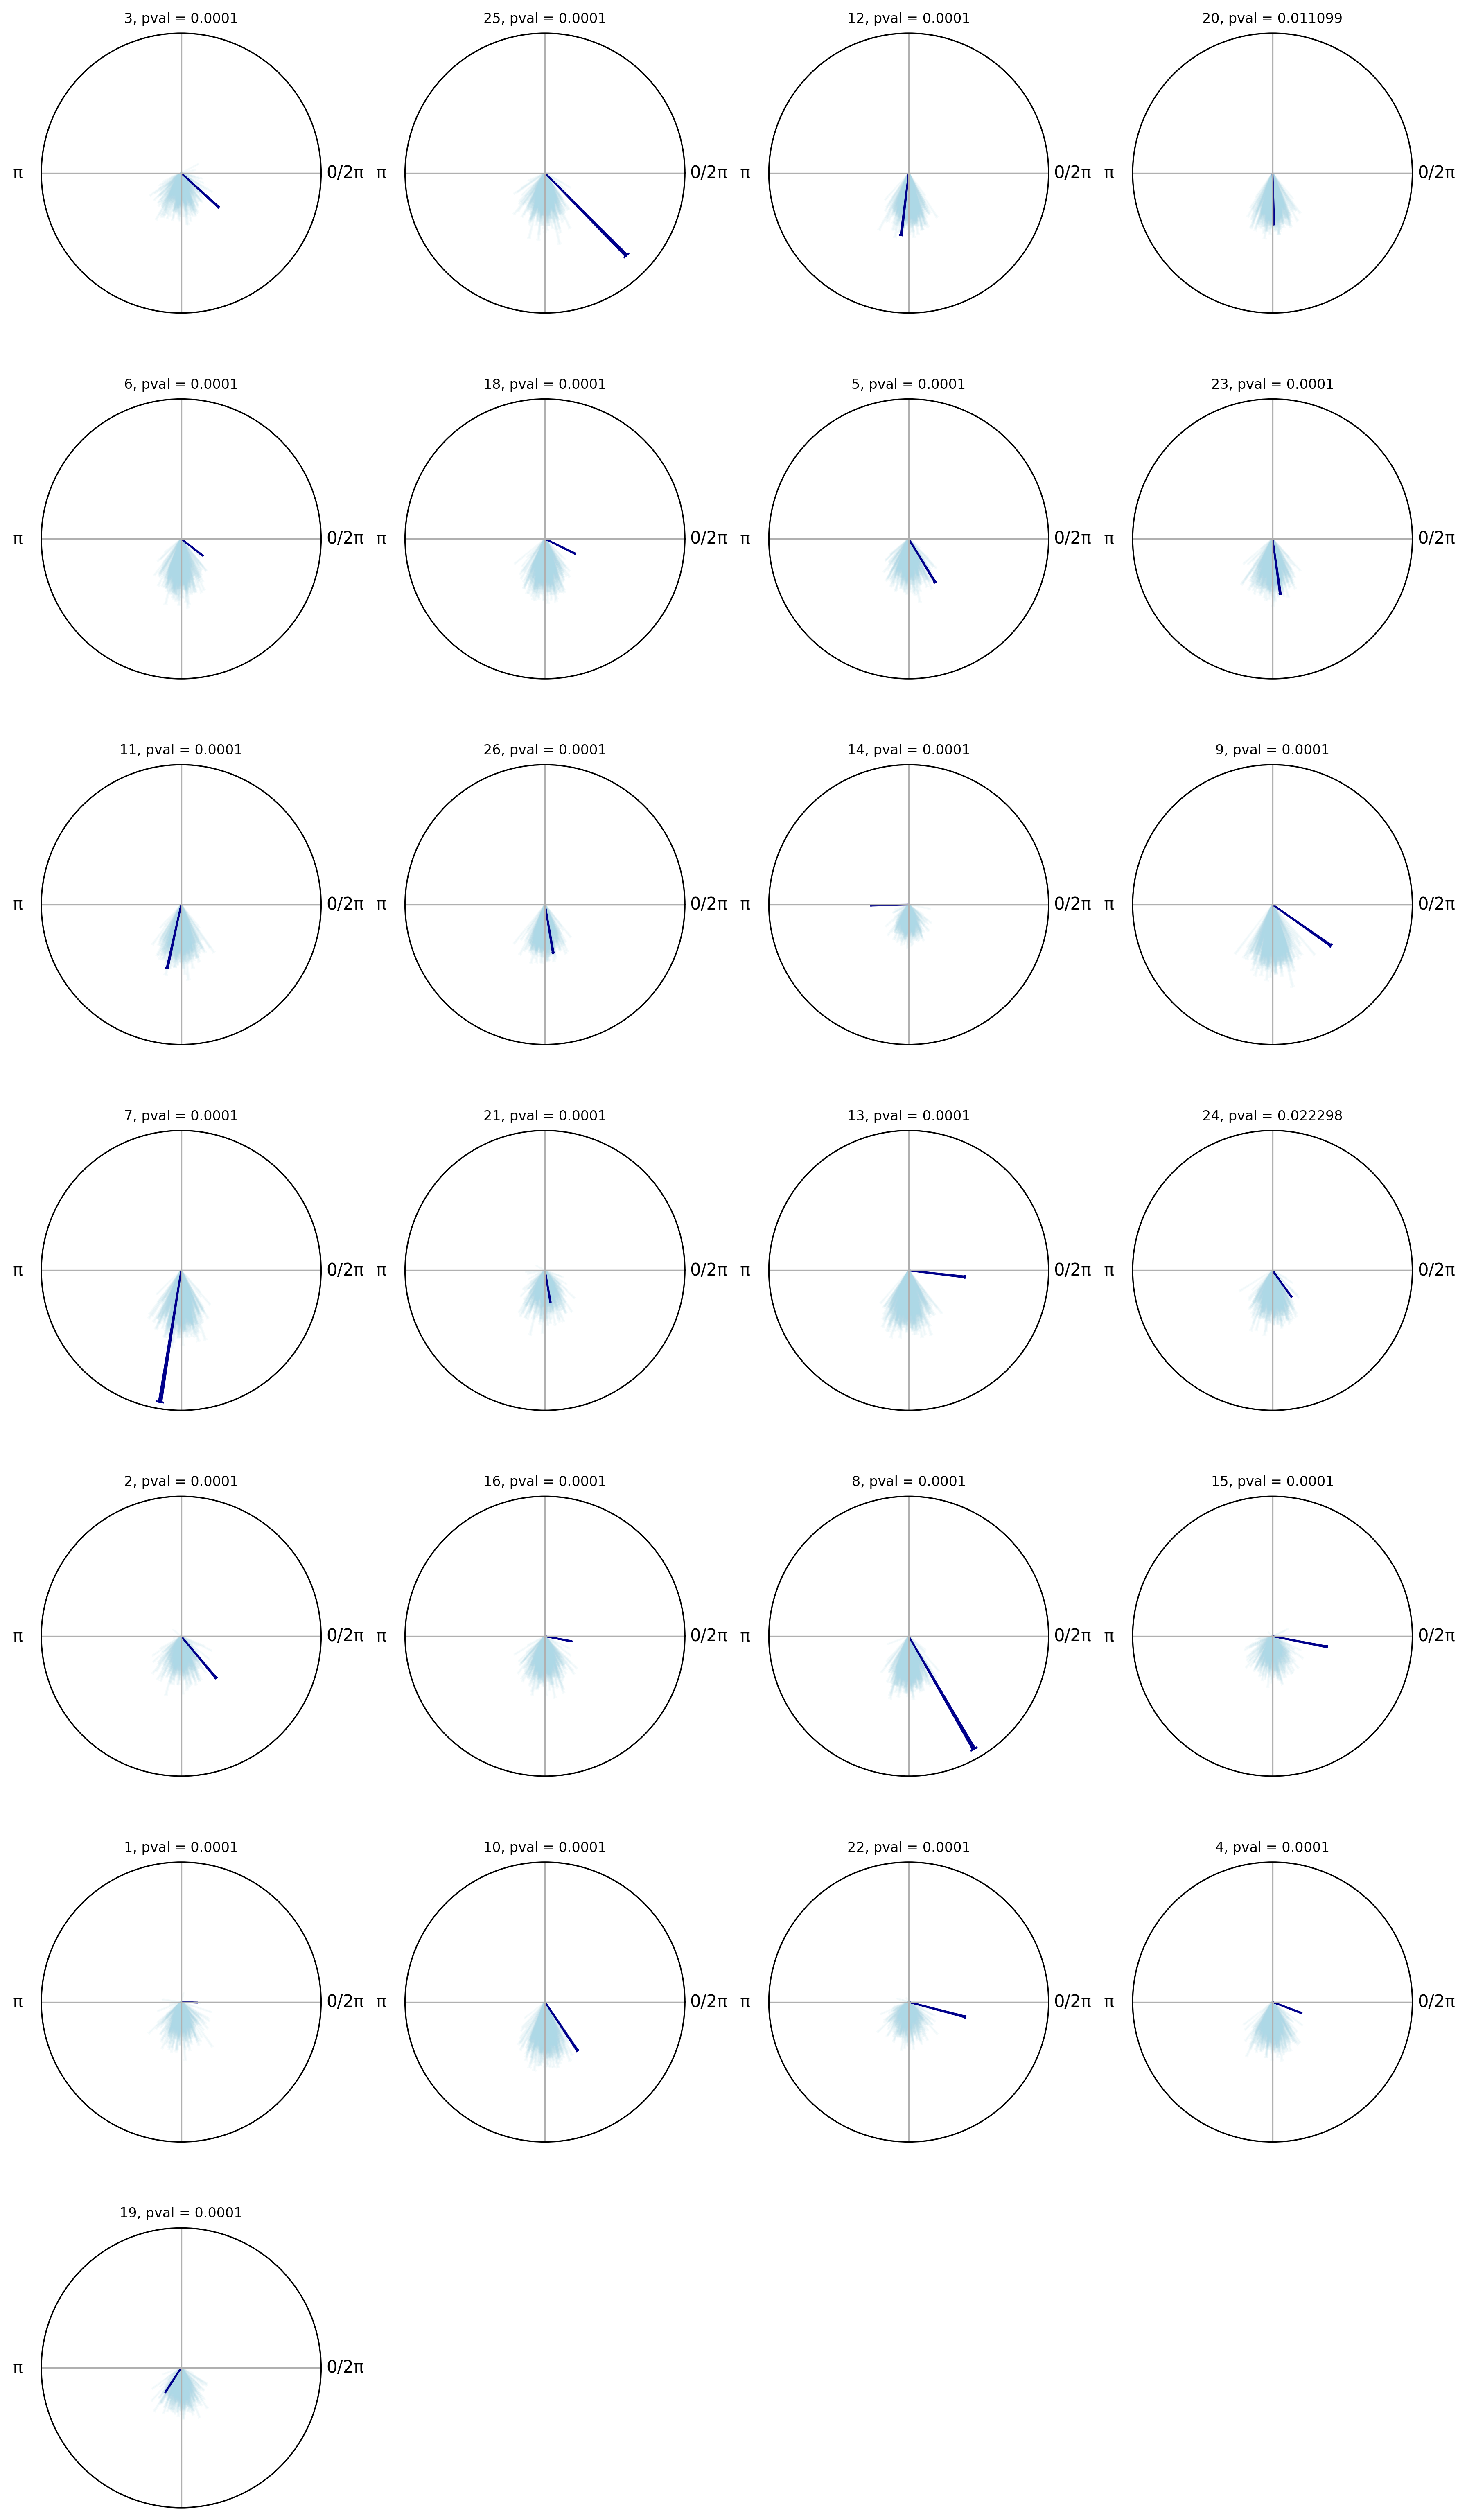

In [7]:
n_subjects = len(results)

n_cols = 4 
n_rows = math.ceil(n_subjects / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols, 
    dpi = 300, 
    figsize = (n_cols*3, n_rows*3), 
    subplot_kw={'projection': 'polar'},
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, subj_id in enumerate(circulars):
    tmp_result = results[subj_id]
    circ_obs_target = circulars[subj_id]["target"]
    circ_null = tmp_result["null_samples"]
    
    
    ax = axes[i]
    tmp_plot = CircPlot(circ_null, ax=ax)
    tmp_plot.add_circular_mean(alpha = 0.1, color = "lightblue")
    tmp_plot.add_arrows([circ_obs_target.mean()], [circ_obs_target.r()], label = "Observed", color = "darkblue")

    ax.set_title(f"{subj_id}, pval = {tmp_result['pval'].round(6)}", fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")


plt.tight_layout()
